In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import re
import scipy.stats as ss

import warnings
warnings.simplefilter('ignore')
#opt+up/down to move cell up/down

sns.set_context('talk')

In [31]:
# folder = 'conf'
folder = 'expl'

In [32]:
def get_performance_df(df_idv, df_group, save_folder):
    #organize performance df
    idv_risk = df_idv.loc[df_idv.trial>60].groupby(['subID', 'predatorType'], as_index=False)[['choice', 'reward', 'attack']].mean()
    idv_risk = idv_risk.rename({'attack': 'idv_attack'}, axis=1)
    # grp_risk = df_group.loc[df_group.step_rt<8].groupby(['sub', 'predatorType', 'room'], as_index=False)[['playerStep', 'jointMoney', 'finalStep', 'selfBlame','playerKeep2', 'partnerStep', 'attack']].mean()
    df_group['attack'] = df_group['attack'].astype(bool)
    grp_risk = df_group.query('step_rt<8 and playerStep>0').groupby(['subID', 'predatorType', 'room'],
                                                        as_index=False)[['playerStep', 'jointMoney', 'finalStep','partnerStep', 'attack']].mean()

    g = pd.merge(idv_risk, grp_risk)
    g = g.sort_values(by=['room', 'predatorType', 'choice'])
    #append local and global riskiness
    g['risky_wpair'] = ['lower', 'higher'] * (2*len(g.room.unique()))
    g['risky_abs'] = g.apply(lambda x: 'high' if ((x['predatorType']==0 and x['choice']>=6.5) or (x['predatorType']==1 and x['choice']>=4.5)) else 'low', axis=1)
    #get group idn choice diff
    g['grp_idv_step_diff'] = g['playerStep'] - g['choice']
    g['jointMoney'] = g['jointMoney'] /2
    #get self partner risk diff
    g['grp_idv_reward_diff'] = g['jointMoney'] - g['reward']
    g['grp_idv_attack_diff'] = g['attack'] - g['idv_attack']
    g['self_partner_risk_diff'] = g.groupby(['room', 'predatorType'])['choice'].diff()
    g['self_partner_risk_diff'] = g.groupby(['room', 'predatorType'])['self_partner_risk_diff'].transform(lambda x: x.fillna(-x.iloc[-1]))

    #get mean abs ppd and pe
    t = df_group.groupby(['subID', 'predatorType'], as_index=False
                        )['player_partner_diff'].apply(lambda x: np.mean(np.absolute(x)))
    g = pd.merge(t, g)
    df_group['pred_partner_diff'] = df_group['prediction'] - df_group['partnerStep']
    t = df_group.loc[df_group.prediction!=-1].groupby(['subID', 'predatorType'], as_index=False)['pred_partner_diff'].apply(lambda x: np.mean(np.absolute(x)))
    g = pd.merge(g, t)

    # #get blame and blame asynchrony
    t = df_group.query('selfBlame!=-1').groupby(['room', 'trial', 'predatorType'], 
                                                as_index=False)['selfBlame'].sum()
    t['blame_async'] = np.absolute(1 - t['selfBlame'])
    t = t.groupby('room', as_index=False)['blame_async'].mean()
    g = pd.merge(t, g, how='right')
    t = df_group.query('selfBlame!=-1').groupby(['room', 'predatorType'], 
                                                as_index=False)['selfBlame'].mean()
    g = pd.merge(t, g, how='right')

    #get variance. maybe better to used the first 60 rounds in idv?
    grp_unc = df_group.groupby(['subID', 'predatorType', 'room'], as_index=False)[['playerStep', 'partnerStep']].var()
    grp_unc = grp_unc.rename({'playerStep': 'playerStep_var', 'partnerStep': 'partnerStep_var'}, axis=1)
    idv_unc= df_idv.loc[df_idv.trial>=60].groupby(['subID', 'predatorType'], as_index=False)['choice'].var()
    idv_unc = idv_unc.rename({'choice': 'idvStep_var'}, axis=1)
    g = pd.merge(pd.merge(g, grp_unc), idv_unc)
    g = g.rename({'reward':'idvMoney', 'choice':'idvStep', 'player_partner_diff':'abs_player_partner_diff', 'pred_partner_diff':'abs_prediction_error'}, axis=1)

    #append variance of ppd and final step
    t = df_group.loc[df_group.playerID==0].copy()
    t['abs_ppd'] = np.absolute(t['player_partner_diff'])
    grp_var = t.groupby(['predatorType', 'room'], as_index=False)[['finalStep', 'abs_ppd']].var()
    grp_var = grp_var.rename({'finalStep':'finalStep_var', 'abs_ppd':'abs_ppd_var'}, axis=1)
    g = pd.merge(g, grp_var, how='left')

    g.to_csv(f'../processed_data/group_perf_{save_folder}.csv')
    return g


In [33]:
if folder == 'conf':
    #read qs
    qs1 = pd.read_csv("../processed_data/parsed_questionnaire_rep2.csv", index_col=[0])
    qs1['subID'] = qs1['subID'] + 400
    qs_orig = pd.concat([qs1,
        pd.read_csv("../processed_data/parsed_questionnaire_conf.csv", index_col=[0])
    ]) 
    #read data
    df_group1 = pd.read_csv("../processed_data/parsed_group_rep2.csv", index_col=[0])
    df_group1['room'] = df_group1['room'] + 200
    df_group1['subID'] = df_group1['subID'] + 400

    df_group2 = pd.read_csv("../processed_data/parsed_group_conf.csv", index_col=[0])
    df_group = pd.concat([df_group1, df_group2])

    df_idv1 = pd.read_csv("../processed_data/parsed_idv_rep2.csv", index_col=[0])
    df_idv1['subID'] = df_idv1['subID'] + 400

    df_idv2 = pd.read_csv("../processed_data/parsed_idv_conf.csv", index_col=[0])
    df_idv = pd.concat([df_idv1, df_idv2])

    # overall stats
    df_perf1 = get_performance_df(df_idv1, df_group1, 'rep2')
    df_perf2 = get_performance_df(df_idv2, df_group2, 'conf')
    df_perf = pd.concat([df_perf1, df_perf2])

    
elif folder == 'expl':
    #read qs
    qs_orig = pd.read_csv('../processed_data/parsed_questionnaire.csv', index_col=[0])
    #read data
    df_group = pd.read_csv('../processed_data/parsed_group.csv', index_col=[0])
    df_idv = pd.read_csv('../processed_data/parsed_idv.csv', index_col=[0])
    # overall stats
    df_perf = get_performance_df(df_idv, df_group, 'expl')




In [34]:
print(f"{len(qs_orig['subID'].unique())} subjects with {len(qs_orig)} rows")
qs_orig.head()

227 subjects with 235 rows


,ptn_rating,svo_value,svo_type,utility,trait,ius_score,subID
0,3,27.847578,prosocial,24.0,52,76,1.0
1,7,35.011535,prosocial,inf,56,88,0.0
2,10,35.011535,prosocial,16.0,46,81,2.0
3,8,15.475255,individualistic,22.0,26,42,3.0
4,5,29.432568,prosocial,20.0,47,58,7.0


In [35]:

# subs = df_group['sub'].unique()
# id_mapping = dict(zip(subs, range(len(subs))))
# df_group['subID'] = df_group['sub'].apply(lambda x: id_mapping[x])
# df_idv = df_idv.query('sub in @subs')
# df_idv['subID'] = df_idv['sub'].apply(lambda x: id_mapping[x])
print(len(df_group['subID'].unique()))
df_group.columns

250


Index(['attack', 'selfBlame', 'jointMoney', 'partnerStep', 'playerStep',
       'prediction', 'split_rt', 'step_rt', 'trial', 'room', 'block',
       'playerID', 'confidence', 'predatorType', 'finalStep',
       'player_partner_diff', 'subID', 'pred_partner_diff'],
      dtype='object')

In [36]:
# some people completed the questionnaire without doing the task
# qs_orig.query('sub not in @intersection')

In [37]:
#read data parsed from analyze_data_nofbwblame

#merge to get subID
data = pd.merge(df_perf, qs_orig, on='subID')
data['predator'] = data['predatorType'].apply(lambda x: 'low-threat' if x==0 else 'high-threat')
print(f"{len(data['subID'].unique())} subjects with {len(data)} rows")
# data.columns

226 subjects with 452 rows


# Correlation 


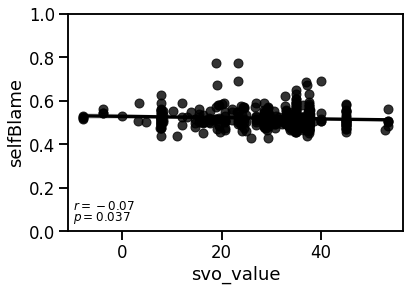

In [9]:
# # svo
# sns.regplot(data = data, x='svo_value', y='playerKeep2', color='black')
# plt.ylabel('player selfishness')
# plt.ylim([0, 1.1])
# r_value, p_value = ss.pearsonr(data['svo_value'], data['playerKeep2'])
# #annotate
# myleft = (plt.gca().get_xlim()[0]) *0.9
# plt.text(myleft, 0.1, f'$r = {r_value:.2f}$', fontsize=12)
# if p_value>=0.001:
#     plt.text(myleft, 0.05, f'$p = {p_value:.2g}$', fontsize=12)
# else:
#     plt.text(myleft, 0.05, f'$p < 0.001$', fontsize=12)


plt.figure()
d = data.groupby(['subID', 'svo_value'], as_index=False)['selfBlame'].mean()
sns.regplot(data = d, x='svo_value', y='selfBlame', color='black')
plt.ylim([0, 1])
r_value, p_value = ss.pearsonr(data['svo_value'], data['selfBlame'])
#annotate
myleft = (plt.gca().get_xlim()[0]) *0.9
plt.text(myleft, 0.1, f'$r = {r_value:.2f}$', fontsize=12)
if p_value>=0.001:
    plt.text(myleft, 0.05, f'$p = {p_value:.2g}$', fontsize=12)
else:
    plt.text(myleft, 0.05, f'$p < 0.001$', fontsize=12)


In [10]:
# regression: blame ~ svo + player_partner_diff * attack

import statsmodels.formula.api as smf
test = df_group.query('selfBlame!=-1')
test = pd.merge(test, data[['subID', 'svo_value']])
# Run the regression using the formula
model = smf.ols(formula='selfBlame ~ svo_value * attack + player_partner_diff * attack', data=test,
                groups = test['subID'])

result = model.fit()

# Print the summary of the model
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:              selfBlame   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     2226.
Date:                Thu, 18 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:06:20   Log-Likelihood:                 11511.
No. Observations:               56494   AIC:                        -2.301e+04
Df Residuals:                   56488   BIC:                        -2.296e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

/Users/wenningdeng/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)


In [11]:
df_perf.columns

Index(['room', 'predatorType', 'selfBlame', 'blame_async', 'subID',
       'abs_player_partner_diff', 'idvStep', 'idvMoney', 'idv_attack',
       'playerStep', 'jointMoney', 'finalStep', 'partnerStep', 'attack',
       'risky_wpair', 'risky_abs', 'grp_idv_step_diff', 'grp_idv_reward_diff',
       'grp_idv_attack_diff', 'self_partner_risk_diff', 'abs_prediction_error',
       'playerStep_var', 'partnerStep_var', 'idvStep_var', 'finalStep_var',
       'abs_ppd_var'],
      dtype='object')

In [12]:
# c = pd.merge(df_group.groupby(['subID', 'room', 'predatorType'], as_index=False)['playerStep'].mean(),
#          df_idv.groupby(['subID', 'predatorType'], as_index=False)['choice'].mean())
# c['step_inc'] = c['playerStep'] - c['choice']
# c
# # c.groupby(['room'])['step_inc'].mean()

In [13]:
# Run the regression using the formula
test = data.copy()
test['deviation_from_optimal'] = test.apply(lambda row: row['idvStep'] - 8 if row['predatorType']==0 else row['idvStep'] - 5, axis=1)
test['step_inc_directed'] = test.apply(lambda row: -row['grp_idv_step_diff'] if row['risky_wpair']=="higher" else row['grp_idv_step_diff'], axis=1)
# model = smf.ols(formula='svo_value ~ abs_player_partner_diff * risky_wpair', data=test)
model = smf.ols(formula='grp_idv_step_diff ~ C(risky_wpair) * svo_value', data=test)
result = model.fit()

# Print the summary of the model
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:      grp_idv_step_diff   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     34.86
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           2.23e-21
Time:                        17:06:20   Log-Likelihood:                -1559.9
No. Observations:                 956   AIC:                             3128.
Df Residuals:                     952   BIC:                             3147.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

1025
1025


PearsonRResult(statistic=-0.06889815916886655, pvalue=0.11946392647322007)
PearsonRResult(statistic=-0.03512847224750833, pvalue=0.42722649979191724)


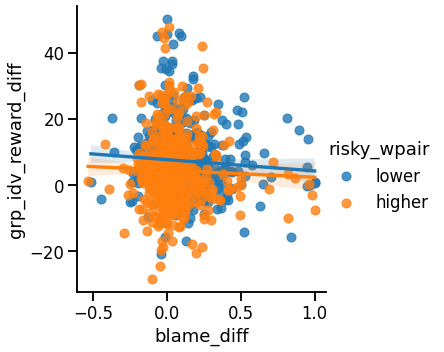

In [14]:
t = df_group.query('selfBlame!=-1').groupby(['subID', 'attack', 'predatorType'], as_index=False)['selfBlame'].mean()
t = pd.merge(t.query('attack==False'), t.query('attack==True'), on=['subID', 'predatorType'])
t['blame_diff'] = t['selfBlame_x'] - t['selfBlame_y']
print(len(t))
# t = pd.merge(df_perf.groupby('sub', as_index=False)['grp_idv_reward_diff'].mean(), t)
t = pd.merge(df_perf, t, how='right')
print(len(t))
sns.lmplot(data=t, x='blame_diff', y='grp_idv_reward_diff', hue='risky_wpair')
print(ss.pearsonr(t.query('risky_wpair=="lower"')['blame_diff'], t.query('risky_wpair=="lower"')['grp_idv_reward_diff']))
print(ss.pearsonr(t.query('risky_wpair=="higher"')['blame_diff'], t.query('risky_wpair=="higher"')['grp_idv_reward_diff']))

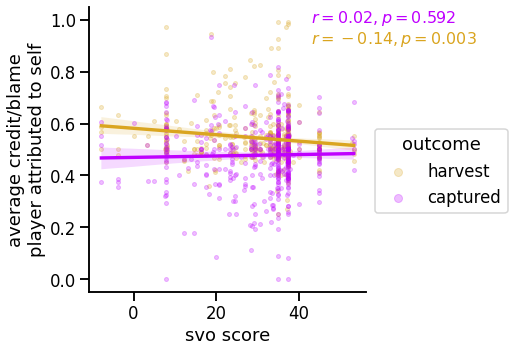

In [15]:
d = df_group.query('selfBlame!=-1').groupby(['subID', 'attack'],as_index=False)['selfBlame'].mean()
d = pd.merge(d, data[['subID', 'svo_value', 'ius_score', 'trait']].drop_duplicates())

outcome_palette = ['goldenrod', "#bf00ff"]
d['outcome'] = d['attack'].apply(lambda x: 'captured' if x else 'harvest')
#plot
g = sns.lmplot(data = d, x='svo_value', y='selfBlame', hue='outcome',
           scatter_kws={'s':16, 'alpha':0.25}, palette=outcome_palette, legend=None)

rt, pt = ss.pearsonr(d.query('attack==True')['svo_value'], 
                  d.query('attack==True')['selfBlame'])
rf, pf = ss.pearsonr(d.query('attack==False')['svo_value'], 
                  d.query('attack==False')['selfBlame'])
plt.annotate(f"$r={round(rt,2)}, p={round(pt,3)}$", (43, 0.99), 
             color=outcome_palette[1], fontsize=16)
plt.annotate(f"$r={round(rf,2)}, p={round(pf,3)}$", (43, 0.91), 
             color=outcome_palette[0], fontsize=16)
plt.ylim([-0.05, 1.05])
plt.ylabel("average credit/blame\nplayer attributed to self")
plt.xlabel('svo score')
# g._legend.set_bbox_to_anchor((1, 0.5))
# g._legend.set_handletextpad(0.5)

plt.legend(markerscale=2, title='outcome', bbox_to_anchor=(1, 0.6)) 
# plt.tight_layout()
plt.savefig(f'../paper_figs/{folder}/blame_svo_{folder}.png',
            dpi=200, bbox_inches='tight')

In [16]:

# import statsmodels.formula.api as smf

# # Run the regression using the formula
# model = smf.ols(formula='svo_value ~ risky_wpair', data=data)

# result = model.fit()

# # Print the summary of the model
# print(result.summary())

In [17]:
# no correlation
# sns.lmplot(data = data, x='ius_score', y='playerKeep2', hue='predatorType')
# plt.figure()
# sns.lmplot(data = data, x='trait', y='playerKeep2', hue='predatorType')

# sns.lmplot(data = data, x='svo_value', y='grp_idv_step_diff', hue='predatorType')
# sns.regplot(data=data.query('risky_wpair=="lower"'), y='grp_idv_step_diff', x='svo_value')
# sns.regplot(data=data.query('risky_wpair=="higher"'), y='grp_idv_step_diff', x='svo_value')
# plt.figure()
# sns.lmplot(data = data, x='trait', y='playerKeep2', hue='predatorType')

ius: PearsonRResult(statistic=-0.06601262359220209, pvalue=0.14957299799812135)
trait anxiety: PearsonRResult(statistic=-0.003228838064743414, pvalue=0.9438688247070425)


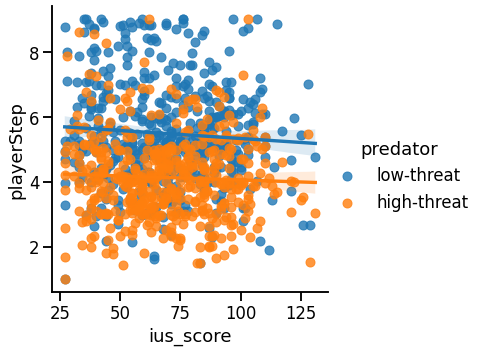

<Figure size 432x288 with 0 Axes>

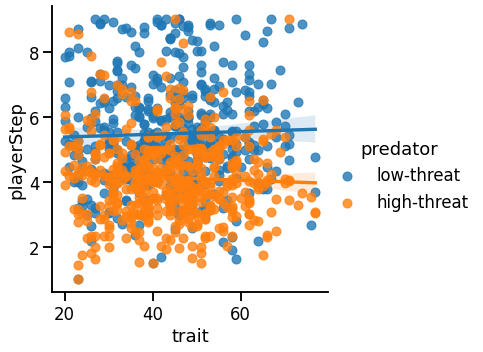

In [18]:
#ius and stai
sns.lmplot(data = data, x='ius_score', y='playerStep', hue='predator')
plt.figure()
sns.lmplot(data = data, x='trait', y='playerStep', hue='predator')

d = data.groupby('subID')[['ius_score','playerStep']].mean()
print(f"ius: {ss.pearsonr(d['ius_score'], d['playerStep'])}")
d = data.groupby('subID')[['trait','playerStep']].mean()
print(f"trait anxiety: {ss.pearsonr(d['trait'], d['playerStep'])}")

trait anxiety: PearsonRResult(statistic=0.050733144444120144, pvalue=0.2682946532731678)


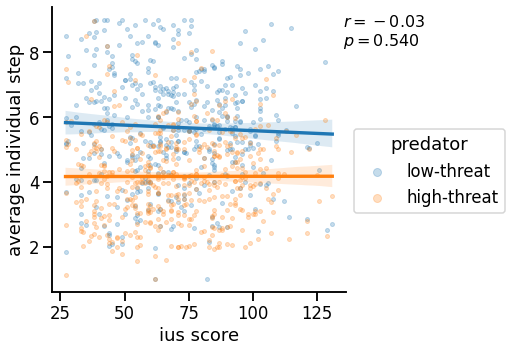

<Figure size 432x288 with 0 Axes>

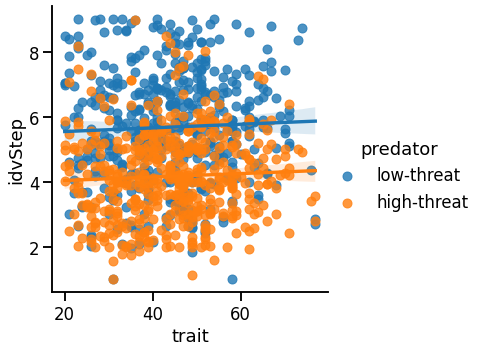

In [19]:
#ius and stai
sns.lmplot(data = data, x='ius_score', y='idvStep', hue='predator'
           , scatter_kws={'s':16, 'alpha':0.25}, legend=None)
d = data.groupby('subID')[['ius_score','idvStep']].mean()
r, p = ss.pearsonr(d['ius_score'], d['idvStep'])
plt.annotate(f'$r = {r:.2f}$', (135, 8.8), fontsize=16)
plt.annotate(f'$p = {p:.3f}$', (135, 8.2),fontsize=16)
plt.ylabel('average individual step')
plt.xlabel('ius score')

plt.legend(markerscale=2, title='predator', bbox_to_anchor=(1, 0.6)) 
# plt.tight_layout()
plt.savefig(f'../paper_figs/{folder}/ius_idvstep_{folder}.png', 
            dpi=200, bbox_inches='tight')

plt.figure()
sns.lmplot(data = data, x='trait', y='idvStep', hue='predator')
r_value, p_value = ss.pearsonr(data['ius_score'], data['idvStep'])
d = data.groupby('subID')[['trait','idvStep']].mean()
print(f"trait anxiety: {ss.pearsonr(d['trait'], d['idvStep'])}")


trait anxiety: PearsonRResult(statistic=-0.06458993975142012, pvalue=0.15856367852118644)


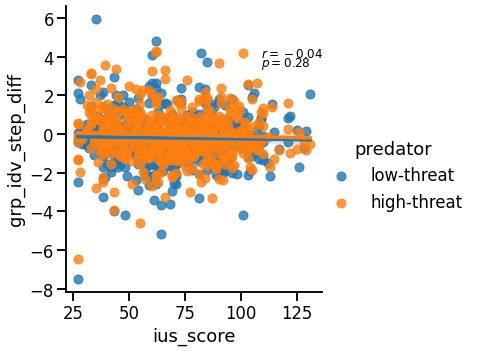

<Figure size 432x288 with 0 Axes>

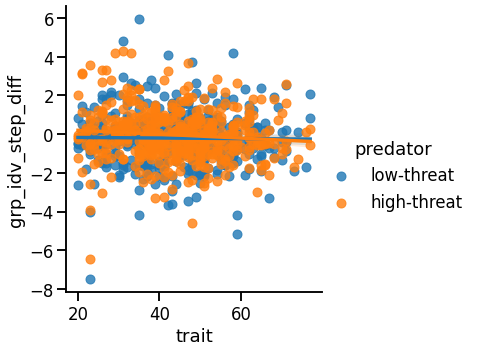

In [20]:
#ius and stai
sns.lmplot(data = data, x='ius_score', y='grp_idv_step_diff', hue='predator')
r_value, p_value = ss.pearsonr(data['ius_score'], data['grp_idv_step_diff'])
myright = (plt.gca().get_xlim()[1]) * 0.8
plt.text(myright, 4, f'$r = {r_value:.2f}$', fontsize=12)
if p_value>=0.001:
    plt.text(myright, 3.5, f'$p = {p_value:.2f}$', fontsize=12)
else:
    plt.text(myright, 3.5, f'$p < 0.001$', fontsize=12)



plt.figure()
sns.lmplot(data = data, x='trait', y='grp_idv_step_diff', hue='predator')

d = data.groupby('subID')[['trait','grp_idv_step_diff']].mean()
print(f"trait anxiety: {ss.pearsonr(d['trait'], d['grp_idv_step_diff'])}")

In [21]:
# quantile_data = data.copy()
# quantile_data['ius_score'] = pd.cut(quantile_data['ius_score'], 
#                                     bins= np.arange(20, 130, 10),
#                                     labels= np.arange(30, 130, 10))
# # quantile_data = quantile_data.groupby('ius_score')
# sns.lineplot(data = quantile_data, x='ius_score', y='player_partner_diff')

group money: PearsonRResult(statistic=-0.02839560738159208, pvalue=0.5357064853061116)
idv money: PearsonRResult(statistic=0.06348961848010454, pvalue=0.1657923812837892)


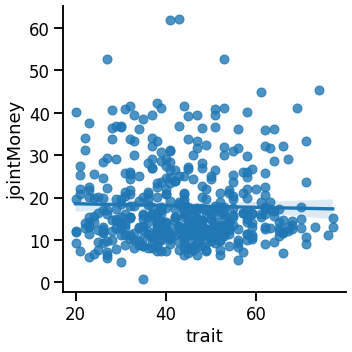

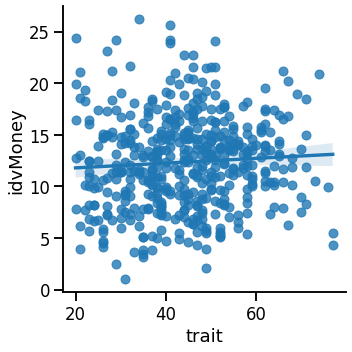

In [22]:
d2 = data.groupby(['subID', 'trait'], 
                  as_index=False)[['jointMoney', 'idvMoney']].mean()
sns.lmplot(data =  d2,
           x='trait', y='jointMoney')

sns.lmplot(data = d2,
           x='trait', y='idvMoney')

print(f"group money: {ss.pearsonr(d2['trait'], d2['jointMoney'])}")
print(f"idv money: {ss.pearsonr(d2['trait'], d2['idvMoney'])}")

trait anxiety: PearsonRResult(statistic=-0.04851271739630078, pvalue=0.2898320572116696)


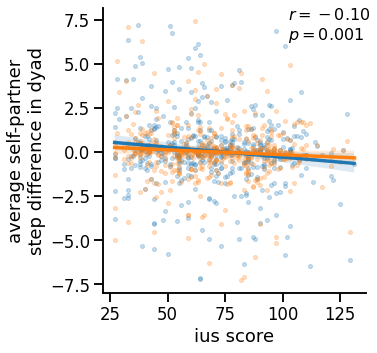

<Figure size 432x288 with 0 Axes>

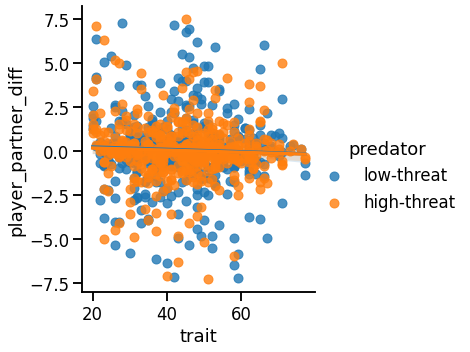

In [23]:
data['player_partner_diff'] = data['playerStep'] - data['partnerStep']

sns.lmplot(data = data, x='ius_score', y='player_partner_diff', hue='predator'
           ,scatter_kws={'s':16, 'alpha':0.25}, legend=None)
r_value, p_value = ss.pearsonr(data['ius_score'], data['player_partner_diff'])
myright = (plt.gca().get_xlim()[1]) * 0.75
plt.text(myright, 7.5, f'$r = {r_value:.2f}$', fontsize=16)
if p_value>=0.001:
    plt.text(myright, 6.4, f'$p = {p_value:.3f}$', fontsize=16)
else:
    plt.text(myright, 6.4, f'$p < 0.001$', fontsize=16)
plt.ylabel('average self-partner\nstep difference in dyad')
plt.xlabel('ius score')
# plt.legend(markerscale=2, title='predator', bbox_to_anchor=(1, 0.6)) 

plt.savefig(f'../paper_figs/{folder}/ius_grpstep_{folder}.png', 
            dpi=200, bbox_inches='tight')


plt.figure()
sns.lmplot(data = data, x='trait', y='player_partner_diff', hue='predator')
d = data.groupby('subID')[['trait','player_partner_diff']].mean()
print(f"trait anxiety: {ss.pearsonr(d['trait'], d['player_partner_diff'])}")

PearsonRResult(statistic=-0.06086436744470373, pvalue=0.1840333478133656)

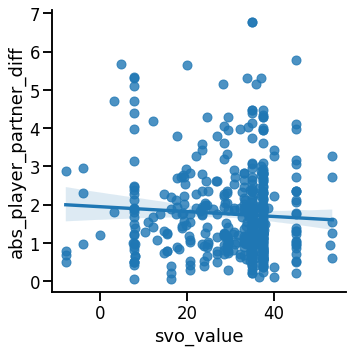

In [24]:
d = data.groupby(['subID', 'svo_value'], as_index=False)['abs_player_partner_diff'].mean()
sns.lmplot(data = d, x='svo_value', y='abs_player_partner_diff')
ss.pearsonr(d['svo_value'], d['abs_player_partner_diff'])

In [25]:
# svo ~ abs_player_partner_diff + risky_wpair

PearsonRResult(statistic=-0.09140500558783965, pvalue=0.004678140724349188)

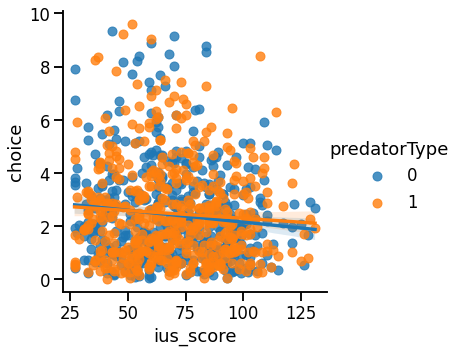

In [26]:
#look at exploration and ius
X = 60
d = df_idv.query('trial<@X').groupby(['subID', 'predatorType'], as_index=False)['choice'].var()
d = pd.merge(d, qs_orig[['subID', 'ius_score']].drop_duplicates())
sns.lmplot(data = d, x='ius_score', y='choice', hue='predatorType')
ss.pearsonr(d['ius_score'], d['choice'])

<Axes: xlabel='trait', ylabel='grp_idv_step_diff'>

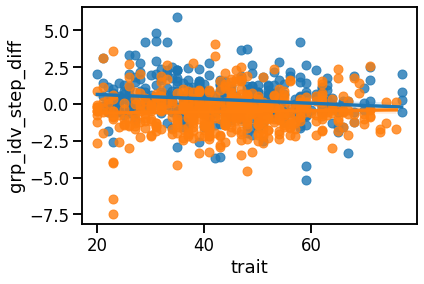

In [27]:
data['compromise'] = data.apply(lambda x: True if ((x['grp_idv_step_diff']>0 and x['risky_wpair']=='lower')\
                                                   or (x['grp_idv_step_diff']<0 and x['risky_wpair']=='higher')) \
                                                    else False, axis=1)
d = data.groupby(['subID', 'predatorType', 'compromise'], as_index=False)[['trait', 'ius_score']].mean()
# sns.pointplot(data = d, x='compromise', y='trait')

sns.regplot(data=data.query('risky_wpair=="lower"'), y='grp_idv_step_diff', x='trait')
sns.regplot(data=data.query('risky_wpair=="higher"'), y='grp_idv_step_diff', x='trait')

pearson: PearsonRResult(statistic=-0.18937892902353823, pvalue=3.081461997899557e-05)
pearson: PearsonRResult(statistic=0.10430592421527468, pvalue=0.022565258874903595)


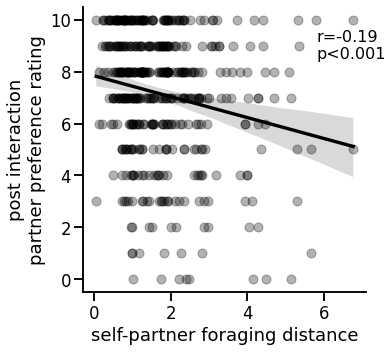

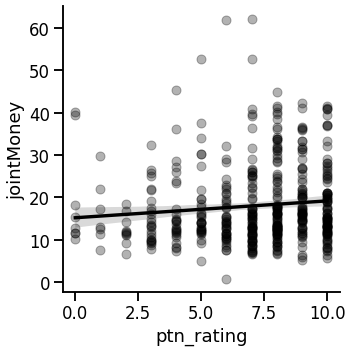

In [28]:
# d = data.groupby('subID')[['ptn_rating', 'partnerStep_var']].mean().dropna()
# sns.lmplot(data = d, x='ptn_rating', y='partnerStep_var')
# print(f"pearson: {ss.pearsonr(d['ptn_rating'], d['partnerStep_var'])}")


# plt.figure(figsize=(6, 4))
d = data.groupby('subID')[['ptn_rating', 'abs_player_partner_diff']].mean().dropna()
sns.lmplot(data = d, y='ptn_rating', x='abs_player_partner_diff', 
           scatter_kws={'alpha':0.3, 'color':'black'}, line_kws={'color':'black'})
print(f"pearson: {ss.pearsonr(d['ptn_rating'], d['abs_player_partner_diff'])}")
r, p = ss.pearsonr(d['ptn_rating'], d['abs_player_partner_diff'])
p = f"p={round(p, 3)}" if p>=0.001 else "p<0.001"
plt.ylabel('post interaction\npartner preference rating')
plt.xlabel('self-partner foraging distance')
plt.annotate(f"r={round(r, 2)}\n{p}", xy=(5.8, 8.5), fontsize=16)
plt.savefig(f'../paper_figs/{folder}/ptn_rating_{folder}.png',
            dpi=200, bbox_inches='tight')

# data['step_inc_towards_partner'] = data.appl(lambda row: row['grp_idv_step_diff'] if row['self_partner_risk_diff']<0 else -row['grp_idv_step_diff'], axis=1)
# d = data.groupby('subID')[['ptn_rating', 'step_inc_towards_partner']].mean().dropna()
# sns.lmplot(data = d, x='ptn_rating', y='step_inc_towards_partner')
# print(f"pearson: {ss.pearsonr(d['ptn_rating'], d['step_inc_towards_partner'])}")

d = data.groupby('subID')[['ptn_rating', 'jointMoney']].mean().dropna()
sns.lmplot(data = d, x='ptn_rating', y='jointMoney', 
           scatter_kws={'alpha':0.3, 'color':'black'}, line_kws={'color':'black'})
print(f"pearson: {ss.pearsonr(d['ptn_rating'], d['jointMoney'])}")

In [29]:
#social benefit2: higher ptn_rating
import statsmodels.formula.api as smf

# Run the regression using the formula
model = smf.ols(formula='ptn_rating ~ abs_player_partner_diff + jointMoney', 
                data=data.groupby(['subID'], as_index=False)[['ptn_rating', 'abs_player_partner_diff', 'jointMoney']].mean())

result = model.fit()

# Print the summary of the model
print(result.summary())



                            OLS Regression Results                            
Dep. Variable:             ptn_rating   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     12.32
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           6.09e-06
Time:                        17:06:30   Log-Likelihood:                -1093.5
No. Observations:                 478   AIC:                             2193.
Df Residuals:                     475   BIC:                             2205.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

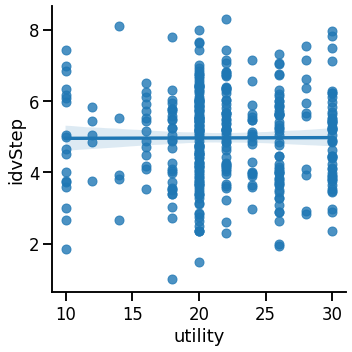

<Figure size 432x288 with 0 Axes>

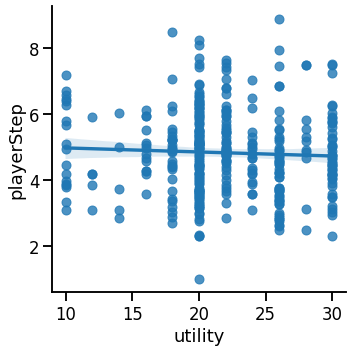

In [30]:
d = data.groupby('subID')[['utility', 'idvStep', 'playerStep']].mean()
sns.lmplot(data=d, x='utility', y='idvStep')
plt.figure()
sns.lmplot(data=d, x='utility', y='playerStep')

# Optimality

In [ ]:
group_stat = df_perf.copy()

Text(66.28319440104168, 0.5, 'compromise')

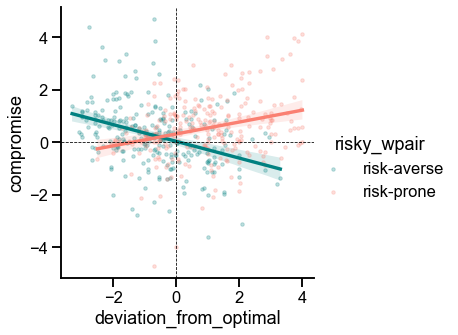

In [ ]:
sns.lmplot(data = group_stat, x='deviation_from_optimal', y='step_inc_towards_partner', hue='risky_wpair',
           scatter_kws={'s':12, 'alpha':0.25}, palette=risk_palette)
plt.axhline(0, ls='--', lw=0.8, color='black')
plt.axvline(0, ls='--', lw=0.8, color='black')
plt.ylabel('compromise')

high-threat: 
PearsonRResult(statistic=0.1785688727471616, pvalue=0.004305535953503654)
low-threat: 
PearsonRResult(statistic=0.2400701515780936, pvalue=0.00010479787832909977)


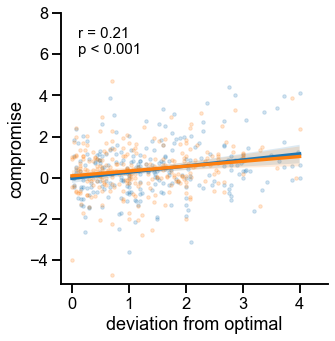

In [ ]:
# sns.lmplot(data = group_stat, x='deviation_from_optimal', y='step_inc_directed', hue='risky_wpair',
#            scatter_kws={'s':15, 'alpha':0.2}, palette=risk_palette)

d = group_stat.copy()
d['deviation_from_optimal'] = np.abs(d['deviation_from_optimal'])
sns.lmplot(data = d, x='deviation_from_optimal', y='step_inc_towards_partner', hue='predator',
           scatter_kws={'s':12, 'alpha':0.2}, legend=False)
plt.ylabel('compromise')
plt.xlabel('deviation from optimal')
print("high-threat: ")
print(ss.pearsonr(d.query('predatorType==1')['deviation_from_optimal'], 
                  d.query('predatorType==1')['step_inc_towards_partner']))
print("low-threat: ")
print(ss.pearsonr(d.query('predatorType==0')['deviation_from_optimal'], 
                  d.query('predatorType==0')['step_inc_towards_partner']))

r, p= ss.pearsonr(d['deviation_from_optimal'], d['step_inc_towards_partner'])
p = f"p = {round(p, 3)}" if p>0.001 else "p < 0.001"
plt.xlim(right=4.5)
plt.ylim(top = 8)
plt.annotate(f"r = {round(r, 2)}\n{p}", xy=(0.1, 6), fontsize=15)


if save:
    plt.savefig(f'../paper_figs/{folder}/compromise_optimal_{folder}.png', 
                bbox_inches='tight', dpi=200)

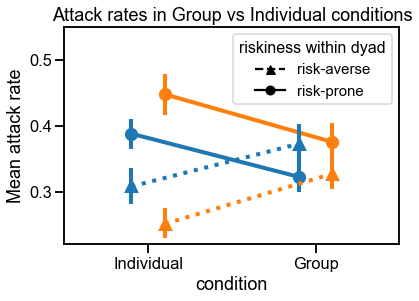

In [ ]:


# Compute means
df_grp_mean = (
    df_group.groupby(['subID', 'predator'], as_index=False)['attack']
    .mean()
    .assign(condition='Group')
)

df_idv_mean = (
    df_idv.groupby(['subID', 'predator'], as_index=False)['attack']
    .mean()
    .assign(condition='Individual')
)

# Combine
df_all = pd.concat([df_idv_mean, df_grp_mean], ignore_index=True)
df_all = pd.merge(df_all, group_stat[['subID', 'predator', 'risky_wpair']], how='left')
# Plot
plt.figure(figsize=(6,4))
sns.pointplot(
    data=df_all.query('risky_wpair=="risk-prone"'),
    hue='predator',
    y='attack',
    x='condition',
    legend=False,
    dodge=0.2
    # ci='ci'   # or "se" / None, depending on what you want
)

sns.pointplot(
    data=df_all.query('risky_wpair=="risk-averse"'),
    hue='predator',
    y='attack',
    x='condition',
    marker = '^',
    ls=':',
    legend=False,
    dodge=0.2
    # ci='ci'   # or "se" / None, depending on what you want
)
plt.ylabel("Mean attack rate")
plt.ylim(top=0.55)
# plt.xlabel("Predator type")
plt.title("Attack rates in Group vs Individual conditions")
legend_handles = [
    Line2D([0], [0], color='black', ls='--', marker='^', label='risk-averse'),
    Line2D([0], [0], color='black', ls='-', marker='o', label='risk-prone')
]
plt.legend(handles = legend_handles, title='riskiness within dyad', title_fontsize=16, fontsize=15)



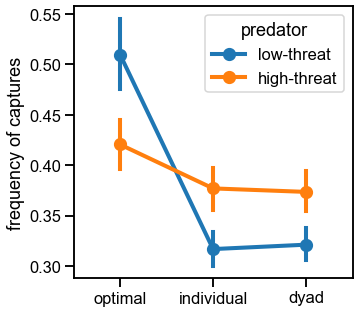

In [ ]:
# sns.barplot(data = df_group.query('(predatorType==0 and finalStep==8) or (predatorType==1 and finalStep==5)'), x='predatorType', y='attack')
# sns.barplot(data = df_group.groupby(['subID', 'predatorType'], as_index=False)['attack'].mean(), x='predatorType', y='attack')
# sns.barplot(data = df_idv.groupby(['subID', 'predatorType'], as_index=False)['attack'].mean(), x='predatorType', y='attack')

# 1. Prepare your three datasets with a new column "source"
d1 = df_group.query('(predatorType==0 and finalStep==8) or (predatorType==1 and finalStep==5)').copy()
d1['source'] = "optimal"

d2 = df_group.groupby(['subID', 'predator'], as_index=False)['attack'].mean()
d2['source'] = "dyad"

d3 = df_idv.groupby(['subID', 'predator'], as_index=False)['attack'].mean()
d3['source'] = "individual"

# 2. Combine
df_all = pd.concat([d1[['predator','attack','source']],
                    d3[['predator','attack','source']],
                    d2[['predator','attack','source']]])

# 3. Plot
plt.figure(figsize=(5,5))
sns.pointplot(data=df_all, hue='predator', y='attack', x='source', hue_order=['low-threat', 'high-threat'])
plt.ylabel("frequency of captures")
plt.xlabel("")
# plt.title("Attack by predator type across datasets")
plt.legend(title="predator")
# plt.axhline(optimal_att[0], ls='--')
# plt.axhline(optimal_att[1], ls='--')
if save:
    plt.savefig(f'../paper_figs/{folder}/attack_prob_{folder}.png', 
                bbox_inches='tight', dpi=200)